In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset from the CSV file
df = pd.read_csv('sheet-reviews.csv')

# Preprocess the 'Review' column: Convert text strings to numeric and fill missing values with 0.0
df['Reviews_Cleaned'] = pd.to_numeric(df['Review'], errors='coerce').fillna(0.0)

# Clean and normalize business categories
df['Clean_Category'] = df['Clean_Category'].fillna('Unknown').str.strip().str.title()

print(f"Dataset successfully loaded. Total rows: {len(df)}")
df[['Sno', 'Company', 'Clean_Category', 'Reviews_Cleaned']].head()

Dataset successfully loaded. Total rows: 299


,Sno,Company,Clean_Category,Reviews_Cleaned
0,1,Payal kashida kendra and Services,Services,0.0
1,2,Mateshwari Cloth,Store,0.0
2,3,Vastram BEST MEN'S WEAR SHOP IN Bhilwara,Store,0.0
3,4,Heera Medicals,Pharmacy,4.6
4,5,Ram Singh Medicals,Pharmacy,4.7


In [5]:
# Define our target proxy indicator for classification (High baseline reviews indicate high intent)
df['Target_Label'] = (df['Reviews_Cleaned'] >= 4.0).astype(int)

# Isolate features strictly based on reviews
X = df[['Reviews_Cleaned']]
y = df['Target_Label']

# Initialize and fit a Logistic Regression classifier
model = LogisticRegression(random_state=42)
model.fit(X, y)

# Extract continuous predicted probabilities for lead conversion
df['Predicted_Probability'] = model.predict_proba(X)[:, 1]

print("Predictive model successfully trained strictly on review signals.")

Predictive model successfully trained strictly on review signals.


In [6]:
# Sort the entire dataset globally by Predicted_Probability (Descending)
# Breaking any probability ties predictably using the raw review value
df_sorted = df.sort_values(by=['Predicted_Probability', 'Reviews_Cleaned'], ascending=[False, False]).reset_index(drop=True)

# Slice into exact structural buckets requested (Dataset contains 299 rows)
high_priority = df_sorted.iloc[0:83].copy()
medium_priority = df_sorted.iloc[83:194].copy()  # 83 + 111 = 194
low_priority = df_sorted.iloc[194:299].copy()     # 194 + 105 = 299 total records

print(f"Global Sorting Complete:")
print(f"-> Top / High Priority Category Count: {len(high_priority)}")
print(f"-> Medium Priority Category Count: {len(medium_priority)}")
print(f"-> Low / Small Priority Category Count: {len(low_priority)}")

Global Sorting Complete:
-> Top / High Priority Category Count: 83
-> Medium Priority Category Count: 111
-> Low / Small Priority Category Count: 105


In [7]:
# Strict list of columns permitted for the final output
columns_to_export = [
    "Sno",
    "Country",
    "City",
    "Company",
    "CONTACT",
    "Google Maps",
    "Clean_Category",
    "Predicted_Probability"
]

# Apply structural column selection filtering
high_priority_final = high_priority[columns_to_export]
medium_priority_final = medium_priority[columns_to_export]
low_priority_final = low_priority[columns_to_export]

# Export to separate sheets inside a single Excel spreadsheet document
output_filename = 'Categorized_Business_Leads.xlsx'
with pd.ExcelWriter(output_filename) as writer:
    high_priority_final.to_excel(writer, sheet_name='High Priority (83)', index=False)
    medium_priority_final.to_excel(writer, sheet_name='Medium Priority (111)', index=False)
    low_priority_final.to_excel(writer, sheet_name='Low Priority (105)', index=False)

print(f"Excel File successfully created: '{output_filename}'")

Excel File successfully created: 'Categorized_Business_Leads.xlsx'


Visualization generated and saved successfully as 'top_converting_categories.png'.


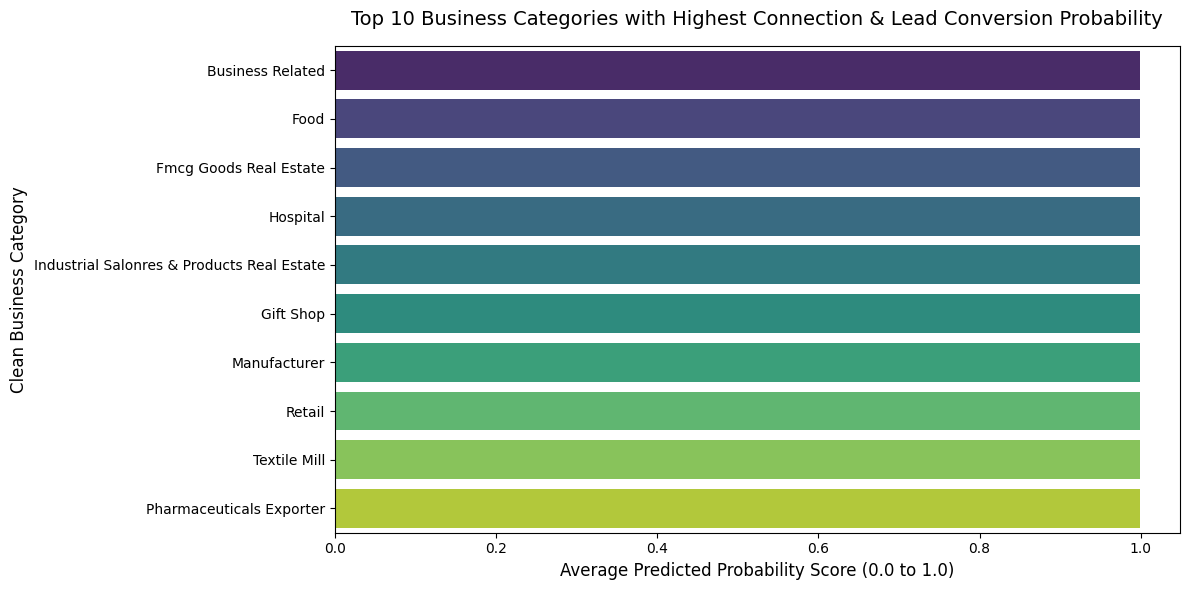

In [8]:
# Recombine priority data streams using only the allowed export columns list
visualization_df = pd.concat([high_priority_final, medium_priority_final])

# Aggregate the mean predicted probability per business category using only the specified columns
category_performance = visualization_df.groupby('Clean_Category')['Predicted_Probability'].mean().reset_index()
category_performance_sorted = category_performance.sort_values(by='Predicted_Probability', ascending=False).head(10)

# Generate chart visualization
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=category_performance_sorted, 
    x='Predicted_Probability', 
    y='Clean_Category', 
    ax=ax, 
    palette='viridis',
    hue='Clean_Category'
)

ax.set_title('Top 10 Business Categories with Highest Connection & Lead Conversion Probability', fontsize=14, pad=15)
ax.set_xlabel('Average Predicted Probability Score (0.0 to 1.0)', fontsize=12)
ax.set_ylabel('Clean Business Category', fontsize=12)

plt.tight_layout()
plt.savefig('top_converting_categories.png', dpi=300)
print("Visualization generated and saved successfully as 'top_converting_categories.png'.")